# Preliminaries

## Dataset

In this set of exercises we will use the same dataset as from [week 3](week_3.ipynb). 


As before, we provide the data already curated in the following two files:

`RNA_expression_curated.csv`: [148 cell lines , 238 genes]

`drug_response_curated.csv`: [148 cell lines , YM155 drug]

The curated data can be read as `pandas` `DataFrame` in the following way:

In [1]:
import pandas as pd

gene_expression = pd.read_csv("./data/RNA_expression_curated.csv", sep=',', header=0, index_col=0)
drug_response = pd.read_csv("./data/drug_response_curated.csv", sep=',', header=0, index_col=0)

The goal of the exercises is to train support vector machine (SVM) and random forests classifiers on this dataset and explore and learn about their hyperparameters. 

## Tools

The `scikit-learn` library provides the required tools for support vector machines, as well as for random forest algorithms.

In [3]:
from sklearn import svm 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs, make_circles
from sklearn.metrics import classification_report

Before proceeding, look up the documentation of the imported functions and read about their basic functionality. Below, we list some important parameters of SVMs and random forests that can be tuned during training.

#### Support Vector Machines (SVM)

`C`: error term.

`kernel`: similarity function ('linear', 'poly', 'sigmoid' or 'rbf')

`gamma`: kernel coef. for 'rbf', 'poly' and 'sigmoid' kernels. It can be thought of as the ‘spread’ of the kernel and therefore the decision region.

`degree`: degree for the 'poly' kernel.

`coef0`: independt term in the 'poly' and 'sigmoid' kernels


#### Random Forests

`n_estimators`: number of trees in our random forest.

`max_depth`: maximum number of levels in each decision tree

`max_features`: maximum number of features to consider per split in an individual tree.

`min_sample_leaf`: minimum number of data points per leaf node

`min_samples_split`: minimum number of data points placed in a node before the node is split

`oob_score`: the out-of-bag (OOB) error is the average error for each observation calculated using predictions from the trees that do not contain that observation in their respective bootstrap sample. Set this parameter to true.

`bootstrap`: method for sampling data points (with or without replacement). Set this parameter to true.

`criterion`: function used to measure the quality of the split (e.g. 'entropy' or 'gini')

# Exercises

## Support vector machines

The  `make_blobs` and `make_circles` functions can be used to generate linearly and not linearly separable toy datasets. 

In [4]:
# data generation: linearly separable
X, Y = make_blobs(n_samples=200, centers=2, n_features=2, random_state=1234)
X = pd.DataFrame(X, columns=['x1', 'x2'])

# splitting data into training and test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=333)

The following code illustrates how to train a linear SVM classifier and plot the data points, the separating hyperplane, the support vectors and the margins that pass through them (considering the training data)

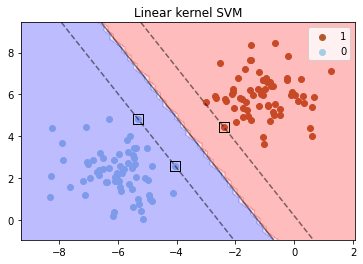

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# build the model
model = svm.SVC(kernel='linear', random_state=33)
model.fit(X_train, Y_train)

# create plot
fig, ax = plt.subplots()

# get colors from qualitative colormap 'Paired'
cmap = plt.cm.get_cmap('Paired')

# plot data points
ax.scatter(X_train.iloc[Y_train == 1, 0], X_train.iloc[Y_train == 1, 1],
           c=[cmap(11)], label='1')
ax.scatter(X_train.iloc[Y_train == 0, 0], X_train.iloc[Y_train == 0, 1],
           c=[cmap(0)], label='0')
ax.legend(loc='best')

# plot the decision function
# create grid to evaluate model
x1_min, x1_max = X_train.iloc[:, 0].min() - 1, X_train.iloc[:, 0].max() + 1
x2_min, x2_max = X_train.iloc[:, 1].min() - 1, X_train.iloc[:, 1].max() + 1

XX, YY = np.meshgrid(np.arange(x1_min, x1_max, .2),
                     np.arange(x2_min, x2_max, .2))

xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model.decision_function(xy).reshape(XX.shape)

# plot decision boundary and margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])

# Establish the class for each point in the contour
Z = model.predict(xy).reshape(XX.shape)

# Visualization of the contour
ax.contourf(XX, YY, Z, cmap='bwr', alpha=0.3)

# plot support vectors, whose are responsible for building the margins
ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
           linewidth=1, facecolors='none', edgecolors='k', marker='s')

ax.axis([x1_min, x1_max, x2_min, x2_max])
plt.axis('tight')
plt.title('Linear kernel SVM')
plt.show()

Train a radial basis function (RBF) SVM classifier with `gamma=0.5` and plot the results in the same way.

In [6]:
# data generation: not linearly separable
X, Y = make_circles(n_samples=200, noise=0.05, random_state=1234)
X = pd.DataFrame(X, columns=['x1', 'x2'])

# splitting data into training and test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=333)

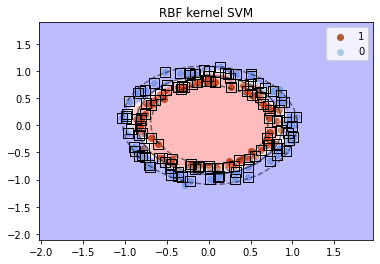

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# build the model
model = svm.SVC(kernel='rbf', random_state=33, gamma = 0.5)
model.fit(X_train, Y_train)

# create plot
fig, ax = plt.subplots()

# get colors from qualitative colormap 'Paired'
cmap = plt.cm.get_cmap('Paired')

# plot data points
ax.scatter(X_train.iloc[Y_train == 1, 0], X_train.iloc[Y_train == 1, 1],
           c=[cmap(11)], label='1')
ax.scatter(X_train.iloc[Y_train == 0, 0], X_train.iloc[Y_train == 0, 1],
           c=[cmap(0)], label='0')
ax.legend(loc='best')

# plot the decision function
# create grid to evaluate model
x1_min, x1_max = X_train.iloc[:, 0].min() - 1, X_train.iloc[:, 0].max() + 1
x2_min, x2_max = X_train.iloc[:, 1].min() - 1, X_train.iloc[:, 1].max() + 1

XX, YY = np.meshgrid(np.arange(x1_min, x1_max, .2),
                     np.arange(x2_min, x2_max, .2))

xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model.decision_function(xy).reshape(XX.shape)

# plot decision boundary and margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])

# Establish the class for each point in the contour
Z = model.predict(xy).reshape(XX.shape)

# Visualization of the contour
ax.contourf(XX, YY, Z, cmap='bwr', alpha=0.3)

# plot support vectors, whose are responsible for building the margins
ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
           linewidth=1, facecolors='none', edgecolors='k', marker='s')

ax.axis([x1_min, x1_max, x2_min, x2_max])
plt.axis('tight')
plt.title('RBF kernel SVM')
plt.show()

<p><font color='#770a0a'>When should a RBF kernel be used over a linear kernel? Motivate your answer.</font></p>

<p><font color='#770a0a'>Do we need to normalize the data before using a kernel function? Motivate your answer.
</font></p>

Answer Q1:

The RBF kernel should be used instead of a linear kernel when the data is not linearly seperable. It uses the squared euclidean distance as a similarity measure, which can be applied to high dimensional and complex data. The linear kernel can not deal with non-linear boundaries such as curves. 

Answer Q2:

Yes the kernel function's similarity measure is based on the squared euclidean distance (RBF) and the inner product of data (linear). When the data is not normalised, one dimension can have great effects over the similarity measure if its range is larger then other dimension. This imposes an implicit importance or bias on the similarity measure which we do not want. Therefore, normalizing data is necessary.

## Predicting drug response on cell lines from gene expression data with SVMs

Explore the hyper-parameter space of an SVM classifier with cross-validation for the Genomics of Drug Sensitivity in Cancer (GDSC) dataset. The`GridSearchCV` function can be used to specify a grid of parameter values with the `param_grid` parameter.

Calculate the precision of your predictions, and compare your calculations with the results of `classification_report`, which displays many classification metrics.


## Random forests

Follow the same steps as for SVM. Compare the two algorithms and report which one has better performance.

The random forests classifiers allows to perform feature selection. Evaluate the importance of features extracting the top 50 informative features. A bar plot (`plt.bar()`) can be a useful tool to visualize this. 


## Biomedical applications

Driven by technological advances, there has recently been a dramatic increase in availability of biomedical data. Machine learning approaches are well suited to take advantage of this data and have been widely applied to many areas of biology. 

Example of these applications are genome annotation, biomarker identification, systems biology, genome data analysis, protein  function  prediction, protein  structure prediction, protein localization prediction, identification of protein interactions and drug discovery.

SVM and RF methods are among the most popular machine learning methods applied in bioinformatics or computational biology.

Perform a literature search and find a biomedical study in which SVM or RF is applied to obtain certain insights. <p><font color='#770a0a'>Explain the motivation behind using that specific algorithm in the study.
</font></p>

## Gridsearch SVM

In [28]:
from sklearn.preprocessing import StandardScaler
# Load data
X = gene_expression
Y = drug_response.values.ravel()

# We decide to transform y into binary to classify
threshold = np.median(drug_response.values)
Y = (drug_response.values.ravel() < threshold).astype(int)

# splitting data into training and test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=333)
#Construct model and parameter grid
model = svm.SVC()
parameters= {'kernel':('linear', 'poly', 'sigmoid', 'rbf'), 'C':[1, 10, 100], 'gamma':[0.1,0.5,1]}

svc = svm.SVC()
clf = GridSearchCV(svc, parameters)
clf.fit(X_train, Y_train)

# Get best estimators
best_model = clf.best_estimator_
#Predict labels for test set
y_pred = best_model.predict(X_test)
#Calculate True and False positives for True = 1
TP = np.sum((y_pred == 1) & (Y_test == 1))
FP = np.sum((y_pred == 1) & (Y_test == 0))

TP, FP

(14, 5)

In [29]:
#Calculate True and False positives for True = 0
TP = np.sum((y_pred == 0) & (Y_test == 0))
FP = np.sum((y_pred == 0) & (Y_test == 1))

TP, FP

(14, 16)

In [30]:
#Print classification report
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.47      0.74      0.57        19
           1       0.74      0.47      0.57        30

    accuracy                           0.57        49
   macro avg       0.60      0.60      0.57        49
weighted avg       0.63      0.57      0.57        49



#### Calculate the precision of your predictions
The following formula is used:
$$
\text{Precision} = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Positives (FP)}}
$$
From our prediction we get 14 True positives and 5 False positives if label 1 corresponds to the true value. 

$$
\text{Precision} = \frac{\text{14}}{\text{19}} = 0.7368421052631579
$$
From our prediction we get 14 True positives and 16 False positives if label 0 corresponds to the true value. 

$$
\text{Precision} = \frac{\text{14}}{\text{30}} = 0.4666666666666667
$$

If we round the calculation to the first decimal it correspond with the precision in the classification report.

## Decision Tree

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_score
#Import data
gene_expression = pd.read_csv("./data/RNA_expression_curated.csv", sep=',', header=0, index_col=0)
drug_response = pd.read_csv("./data/drug_response_curated.csv", sep=',', header=0, index_col=0)

#Change data from continuous to binary for classification
threshold = np.median(drug_response.values)
Y = (drug_response.values.ravel() < threshold).astype(int)

# splitting data into training and test set
X_train, X_test, Y_train, Y_test = train_test_split(gene_expression, Y, test_size=0.33, random_state=333)

In [35]:
#Build searchgrid for random forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': [10, 20, 50],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'oob_score' : [True],
    'bootstrap' : [True],
    'criterion' : ['entropy']
    
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=333),
                       param_grid, cv=5, scoring='precision')
                             
grid_rf.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=333),
             param_grid={'bootstrap': [True], 'criterion': ['entropy'],
                         'max_depth': [5, 10, None],
                         'max_features': [10, 20, 50],
                         'min_samples_leaf': [1, 3, 5],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300], 'oob_score': [True]},
             scoring='precision')

In [36]:
pred = grid_rf.predict(X_test)
print("Best RF parameters:", grid_rf.best_params_)
print("Precision:", precision_score(Y_test, pred))
print(classification_report(Y_test, pred))

Best RF parameters: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 5, 'max_features': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200, 'oob_score': True}
Precision: 0.7222222222222222
              precision    recall  f1-score   support

           0       0.45      0.74      0.56        19
           1       0.72      0.43      0.54        30

    accuracy                           0.55        49
   macro avg       0.59      0.59      0.55        49
weighted avg       0.62      0.55      0.55        49



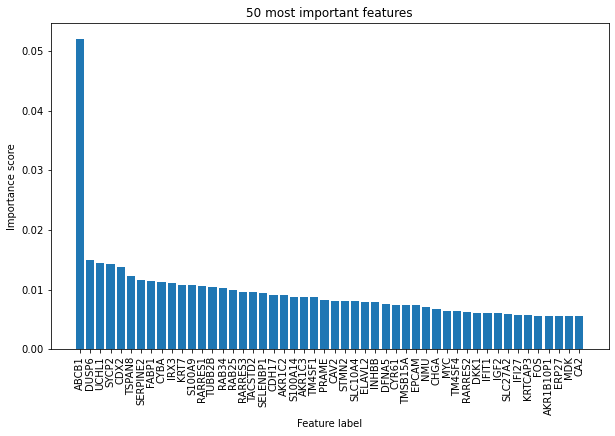

In [38]:
nr_features = 50
# Get important feature from the best RF model
importances = grid_rf.best_estimator_.feature_importances_
gene = list(X_test.columns.values) # get gene name
indices = np.argsort(importances)[::-1][:nr_features]

plt.figure(figsize=(10, 6))
plt.bar(range(nr_features), importances[indices])
plt.title("50 most important features")
plt.xlabel("Feature label")
plt.ylabel("Importance score")
plt.xticks(range(nr_features), [gene[i] for i in indices], rotation=90);
plt.show()


The precision of the decision tree is lower then the SVM, 0.72 instead of 0.74 and 0.45 instead of 0.47, but only slightly. This difference might be larger when different ranges for hyperparameters are tested. Additionally, from the barplot it is clear that the gene "ABCB1" is the most important gene. 